<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1945 | Val: 472 | Test: 90


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 24)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 1.2197 acc 0.531 | val loss 0.8203 acc 0.689 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 0.6132 acc 0.730 | val loss 0.5182 acc 0.799 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.4089 acc 0.831 | val loss 0.4728 acc 0.807 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.3530 acc 0.854 | val loss 0.3659 acc 0.862 *


...

[ConvNeXt-Tiny] Epoch  17/100 | LR: 5.00e-06 | train loss 0.0350 acc 0.985 | val loss 0.4196 acc 0.888


[ConvNeXt-Tiny] Epoch  18/100 | LR: 5.00e-06 | train loss 0.0392 acc 0.987 | val loss 0.4138 acc 0.886


[ConvNeXt-Tiny] Epoch  19/100 | LR: 5.00e-06 | train loss 0.0282 acc 0.987 | val loss 0.4174 acc 0.888


[ConvNeXt-Tiny] Epoch  20/100 | LR: 5.00e-06 | train loss 0.0373 acc 0.987 | val loss 0.4189 acc 0.890


[ConvNeXt-Tiny] Epoch  21/100 | LR: 5.00e-06 | train loss 0.0192 acc 0.990 | val loss 0.4241 acc 0.890

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 21.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3298)


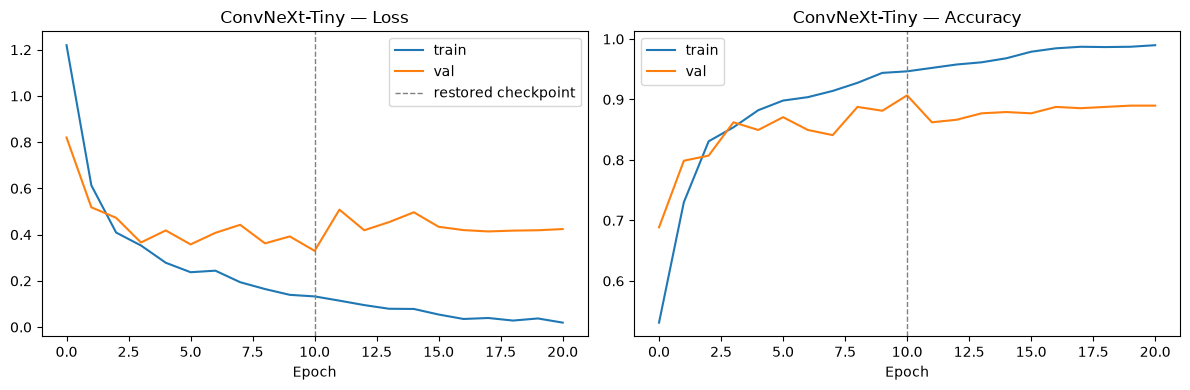

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.889


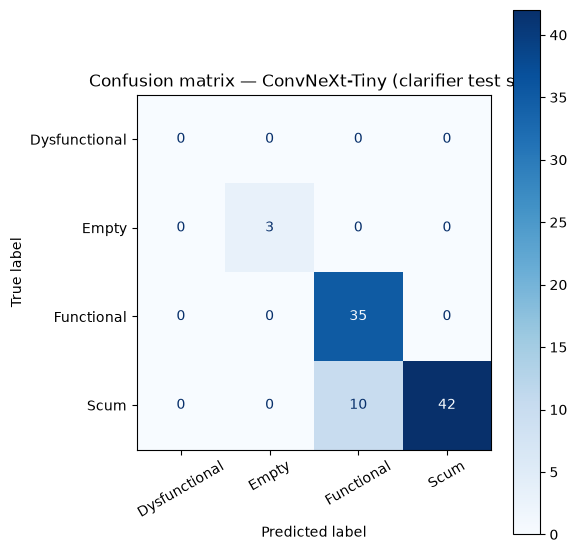

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000         0
        Empty      1.000     1.000     1.000         3
   Functional      0.778     1.000     0.875        35
         Scum      1.000     0.808     0.894        52

     accuracy                          0.889        90
    macro avg      0.694     0.702     0.692        90
 weighted avg      0.914     0.889     0.890        90

  [warn] 'Dysfunctional' has 0 examples in this test set — AUC undefined, skipping.


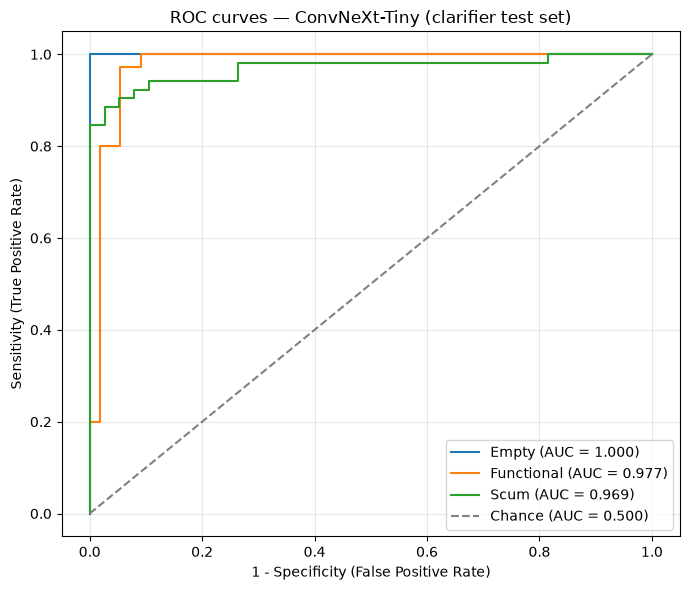

AUC (area under ROC curve) per class:
  Dysfunctional  : undefined (0 examples)
  Empty          : 1.000
  Functional     : 0.977
  Scum           : 0.969

Mean AUC (over 3/4 classes with test examples): 0.982


(np.float64(0.8888888888888888),
 {'Dysfunctional': nan,
  'Empty': 1.0,
  'Functional': 0.9771428571428571,
  'Scum': 0.9686234817813765})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_Atlantis.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
